## Imports

In [1]:
import os
import json
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

In [2]:
# Paths
json_path = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos.json"
image_dir = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos"


## Resizing & Gaussian Blur

In [3]:
# Function to preprocess the images
def preprocess_image(image_path):
    # Load the image
    img = load_img(image_path, target_size=(224, 224))  # Resize to 224x224
    img_array = img_to_array(img)  # Convert image to numpy array
    
    # Apply Gaussian Blur
    img_blurred = cv2.GaussianBlur(img_array, (5, 5), 0)
    
    # Normalize the image
    img_normalized = img_blurred / 255.0
    
    return img_normalized


In [4]:
# Read JSON file line-by-line
with open(json_path, 'r') as file:
    data = []
    for line in file:
        try:
            data.append(json.loads(line))  # Load each line separately
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON: {e}")

In [5]:
# Convert the data to a DataFrame for easier manipulation
df = pd.DataFrame(data)

In [6]:
# Print the head of the DataFrame (first 5 rows)
print("DataFrame Head (first 5 rows):")
print(df.head())

DataFrame Head (first 5 rows):
                 photo_id             business_id  \
0  zsvj7vloL4L5jhYyPIuVwg  Nk-SJhPlDBkAZvfsADtccA   
1  HCUdRJHHm_e0OCTlZetGLg  yVZtL5MmrpiivyCIrVkGgA   
2  vkr8T0scuJmGVvN2HJelEA  _ab50qdWOk0DdB6XOrBitw   
3  pve7D6NUrafHW3EAORubyw  SZU9c8V2GuREDN5KgyHFJw   
4  H52Er-uBg6rNrHcReWTD2w  Gzur0f0XMkrVxIwYJvOt2g   

                                             caption    label  
0  Nice rock artwork everywhere and craploads of ...   inside  
1                                                     outside  
2                                     oyster shooter    drink  
3                                      Shrimp scampi     food  
4                                                        food  


## Missing value

In [7]:
missing_labels_count = sum(1 for entry in data if not entry.get('label'))
print(f"Missing labels count: {missing_labels_count}")

Missing labels count: 0


In [8]:
# Prepare lists for storing images and labels
images = []
labels = []


In [9]:
from sklearn.preprocessing import LabelEncoder
# Label encoding
label_encoder = LabelEncoder()


In [11]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Check if images exist and preprocess them

for entry in data:  
    photo_id = entry.get('photo_id').strip()  # Remove extra whitespace, if any  # **Changed `row['photo_id']` to `entry['photo_id']`**
    label = entry.get('label')  # **Changed `row['label']` to `entry['label']`**

    if photo_id and label:  # Only process if both photo_id and label exist
        image_path = os.path.join(image_dir, 'photos', photo_id + '.jpg')  # Use 'photos' subfolder
        print(f"Checking image path: {image_path}")
        
        if os.path.exists(image_path):
            print(f"Found image: {image_path}")
            img = preprocess_image(image_path)  # Preprocess the image
            images.append(img)
            labels.append(label)  # Store the corresponding label
        else:
            print(f"Image not found: {image_path}")


Checking image path: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg
Found image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg
Checking image path: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\HCUdRJHHm_e0OCTlZetGLg.jpg
Found image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\HCUdRJHHm_e0OCTlZetGLg.jpg
Checking image path: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\vkr8T0scuJmGVvN2HJelEA.jpg
Found image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\vkr8T0scuJmGVvN2HJelEA.jpg
Checking image path: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\pve7D6NUrafHW3EAORubyw.jpg
Found image: C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Ye

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x000002BCCDDDFA10>

## Augmentation

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create an image data generator for augmentation
datagen = ImageDataGenerator(
    rotation_range=30,   # Random rotation
    width_shift_range=0.2,  # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,      # Shear transformation
    zoom_range=0.2,       # Zoom in/out
    horizontal_flip=True,  # Random horizontal flip
    fill_mode='nearest'   # Filling missing pixels after transformation
)

# Apply the transformations to your images
augmented_images = []
for img in images:
    img = img.reshape((1,) + img.shape)  # Reshape to match the expected input format for the generator
    # Generate augmented images
    for batch in datagen.flow(img, batch_size=1):
        augmented_images.append(batch[0].astype('float32'))
        break  # Stop after one augmentation per image


## Intensity Threshold

In [13]:
def intensity_threshold(img_array, threshold_value=127):
    # Apply thresholding to the image
    _, thresholded = cv2.threshold(img_array, threshold_value, 255, cv2.THRESH_BINARY)
    return thresholded


## Histogram Equalization

In [14]:
def histogram_equalization(img_array):
    # Convert the image to grayscale
    gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    # Apply histogram equalization
    equalized_img = cv2.equalizeHist(gray_img)
    return equalized_img


## Augmented image visualization

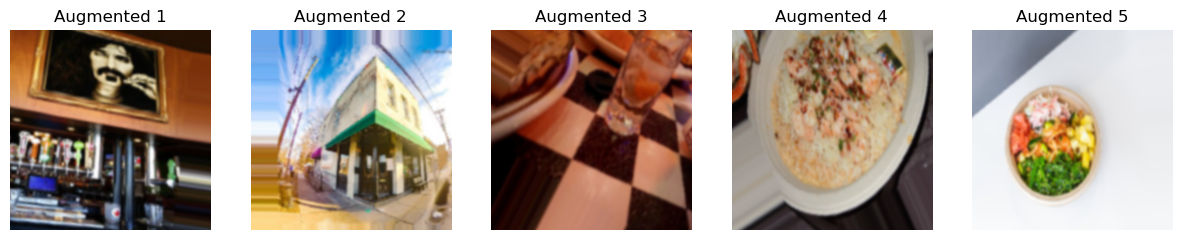

In [15]:
# Function to visualize augmented images
def plot_augmented_images(augmented_images, num_images=5):
    """
    Visualize the augmented images in a grid.
    
    Parameters:
    - augmented_images: List of augmented images
    - num_images: Number of images to display (default: 5)
    """
    plt.figure(figsize=(15, 15))
    for i, img in enumerate(augmented_images[:num_images]):
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.title(f"Augmented {i+1}")
        plt.axis('off')
    plt.show()

# Visualize the first 5 augmented images
plot_augmented_images(augmented_images, num_images=5)


## Intensity Threshold Visualization

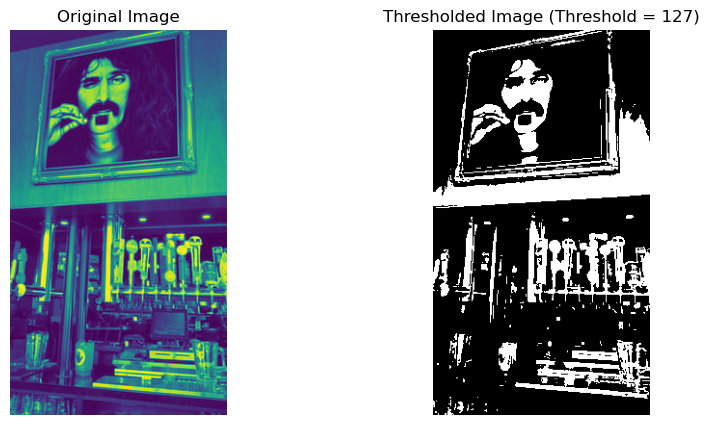

In [16]:
import cv2
import matplotlib.pyplot as plt

def intensity_threshold(img_array, threshold_value=127):
    """
    Apply intensity thresholding to the image.
    
    Parameters:
    - img_array: The input image array (as a NumPy array)
    - threshold_value: The threshold value for binary thresholding (default: 127)
    
    Returns:
    - thresholded: The thresholded image
    """
    # Apply thresholding to the image
    _, thresholded = cv2.threshold(img_array, threshold_value, 255, cv2.THRESH_BINARY)
    return thresholded

# Function to visualize original and thresholded images
def plot_intensity_threshold(img_array, threshold_value=127):
    thresholded_img = intensity_threshold(img_array, threshold_value)
    
    # Plot original and thresholded images side by side
    plt.figure(figsize=(10, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.title("Original Image")
    plt.axis('off')

    # Thresholded image
    plt.subplot(1, 2, 2)
    plt.imshow(thresholded_img, cmap='gray')
    plt.title(f"Thresholded Image (Threshold = {threshold_value})")
    plt.axis('off')

    plt.show()

# Example: Load an image, convert to grayscale, and visualize
image_path = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg"
img = cv2.imread(image_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert image to grayscale

# Visualize the original and thresholded image
plot_intensity_threshold(img_gray, threshold_value=127)


## Histogram Equalization- visualization

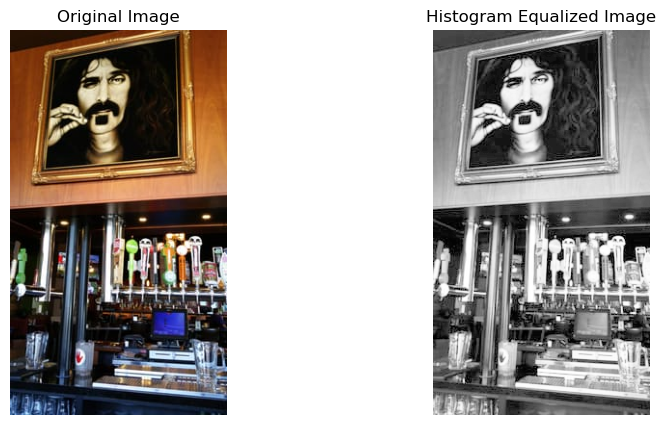

In [17]:
import cv2
import matplotlib.pyplot as plt

def histogram_equalization(img_array):
    """
    Apply histogram equalization to an image.
    
    Parameters:
    - img_array: The input image array (as a NumPy array)
    
    Returns:
    - equalized_img: The histogram equalized image
    """
    # Convert the image to grayscale
    gray_img = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)
    
    # Apply histogram equalization
    equalized_img = cv2.equalizeHist(gray_img)
    
    return equalized_img

# Function to visualize original and histogram equalized images
def plot_histogram_equalization(img_array):
    equalized_img = histogram_equalization(img_array)
    
    # Plot original and equalized images side by side
    plt.figure(figsize=(10, 5))

    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))  # Convert to RGB for correct display
    plt.title("Original Image")
    plt.axis('off')

    # Histogram equalized image
    plt.subplot(1, 2, 2)
    plt.imshow(equalized_img, cmap='gray')
    plt.title("Histogram Equalized Image")
    plt.axis('off')

    plt.show()

# Example: Load an image and visualize histogram equalization
image_path = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg"
img = cv2.imread(image_path)

# Visualize the original and histogram equalized images
plot_histogram_equalization(img)


## Concatenation

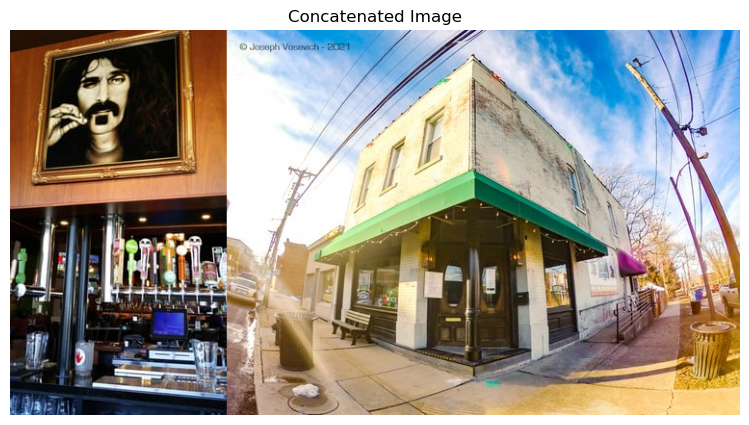

In [17]:
def concatenate_images(img1, img2):
    """Concatenates two images side by side (horizontally)."""
    # Resize images to the same height for proper alignment
    height = min(img1.shape[0], img2.shape[0])  # Use the smaller height
    img1 = cv2.resize(img1, (int(img1.shape[1] * height / img1.shape[0]), height))
    img2 = cv2.resize(img2, (int(img2.shape[1] * height / img2.shape[0]), height))

    # Concatenate the images horizontally
    combined_img = np.hstack((img1, img2))
    
    return combined_img

def visualize_combined_images(img1, img2):
    combined_img = concatenate_images(img1, img2)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(cv2.cvtColor(combined_img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct display
    plt.title("Concatenated Image")
    plt.axis('off')
    plt.show()

# Load two example images
image_path1 = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\zsvj7vloL4L5jhYyPIuVwg.jpg"
image_path2 = r"C:\Users\JISNA\Desktop\sem 3\computer vision\Yelp-Photos\Yelp Photos\yelp_photos\photos\HCUdRJHHm_e0OCTlZetGLg.jpg"

img1 = cv2.imread(image_path1)
img2 = cv2.imread(image_path2)

visualize_combined_images(img1, img2)


In [18]:
# Convert to numpy arrays
X = np.array(images)
y = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

## Spliting

In [19]:
# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Samples: {len(X_train)}, Testing Samples: {len(X_test)}")

Training Samples: 2555, Testing Samples: 639


In [20]:
print(X_train.shape)  # Should be (num_samples, num_features)
print(y_train.shape)  # Should be (num_samples,)

(2555, 224, 224, 3)
(2555,)


In [21]:
X_train = X_train.reshape(X_train.shape[0], -1)  # Reshape to (1277, 150528)
X_test = X_test.reshape(X_test.shape[0], -1)      # Reshape to (num_samples, 150528)

In [22]:
print(X_train.shape)  # Should be (num_samples, num_features)
print(y_train.shape)  # Should be (num_samples,)

(2555, 150528)
(2555,)


## Train Model-KNN

In [23]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)  # K=5
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

print("Model training complete!")


Model training complete!


## Evaluation of model

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.62
Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.18      0.19        33
           1       0.73      0.73      0.73       168
           2       0.58      0.67      0.62        91
           3       0.00      0.00      0.00         5
           4       0.56      0.43      0.49        23

    accuracy                           0.62       320
   macro avg       0.41      0.40      0.41       320
weighted avg       0.61      0.62      0.61       320

Confusion Matrix:
[[  6  20   7   0   0]
 [ 12 122  31   0   3]
 [  7  18  61   0   5]
 [  0   2   3   0   0]
 [  5   4   4   0  10]]


C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\JISNA\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_pred:", np.unique(y_pred))


Unique labels in y_train: [0 1 2 3 4]
Unique labels in y_pred: [0 1 2 3 4]


In [33]:
import numpy as np
from collections import Counter

print("Class distribution in y_train:", Counter(y_train))


Class distribution in y_train: Counter({1: 1367, 2: 706, 0: 250, 4: 207, 3: 25})


## SMOTE

In [34]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE to balance class distribution
smote = SMOTE()
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check new class distribution
print("Class distribution after SMOTE:", Counter(y_train_resampled))


Class distribution after SMOTE: Counter({2: 1367, 1: 1367, 0: 1367, 4: 1367, 3: 1367})


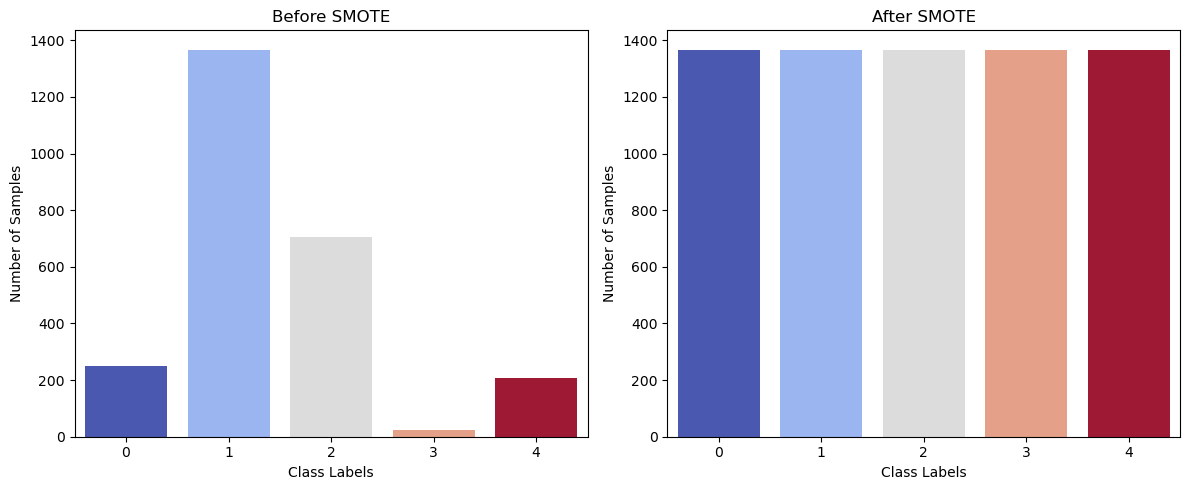

In [35]:
import seaborn as sns

# Function to plot class distributions
def plot_class_distribution(y_before, y_after):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Before SMOTE
    class_counts_before = Counter(y_before)
    classes, counts = zip(*class_counts_before.items())
    sns.barplot(x=list(classes), y=list(counts), hue=list(classes), palette="coolwarm", ax=axes[0], legend=False)
    axes[0].set_title("Before SMOTE")
    axes[0].set_xlabel("Class Labels")
    axes[0].set_ylabel("Number of Samples")

    # After SMOTE
    class_counts_after = Counter(y_after)
    classes, counts = zip(*class_counts_after.items())
    sns.barplot(x=list(classes), y=list(counts), hue=list(classes), palette="coolwarm", ax=axes[1], legend=False)
    axes[1].set_title("After SMOTE")
    axes[1].set_xlabel("Class Labels")
    axes[1].set_ylabel("Number of Samples")

    plt.tight_layout()
    plt.show()

# Call function
plot_class_distribution(y_train, y_train_resampled)


In [36]:
from sklearn.neighbors import KNeighborsClassifier

# Train KNN Model
knn = KNeighborsClassifier(n_neighbors=5)  # K=5
knn.fit(X_train, y_train)

# Predictions
y_pred = knn.predict(X_test)

print("Model training complete!")


Model training complete!


In [37]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report (Precision, Recall, F1-score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.66
Classification Report:
              precision    recall  f1-score   support

           0       0.18      0.33      0.23        40
           1       0.76      0.77      0.77       331
           2       0.67      0.63      0.65       204
           3       0.00      0.00      0.00         3
           4       0.72      0.48      0.57        61

    accuracy                           0.66       639
   macro avg       0.47      0.44      0.44       639
weighted avg       0.69      0.66      0.67       639

Confusion Matrix:
[[ 13  18   7   1   1]
 [ 32 254  40   0   5]
 [ 21  49 128   1   5]
 [  0   3   0   0   0]
 [  7   9  16   0  29]]


## Confusion matrix

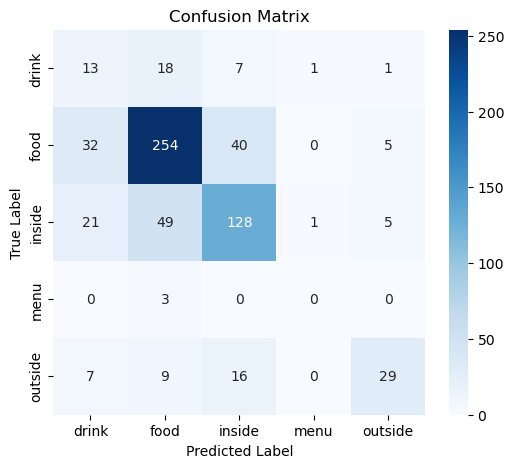

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [36]:
from sklearn.metrics import classification_report

# Print classification report with zero_division set to handle ill-defined precision
print(classification_report(y_test, y_pred, zero_division=0))


              precision    recall  f1-score   support

           0       0.20      0.18      0.19        33
           1       0.73      0.73      0.73       168
           2       0.58      0.67      0.62        91
           3       0.00      0.00      0.00         5
           4       0.56      0.43      0.49        23

    accuracy                           0.62       320
   macro avg       0.41      0.40      0.41       320
weighted avg       0.61      0.62      0.61       320



## ROC Curve

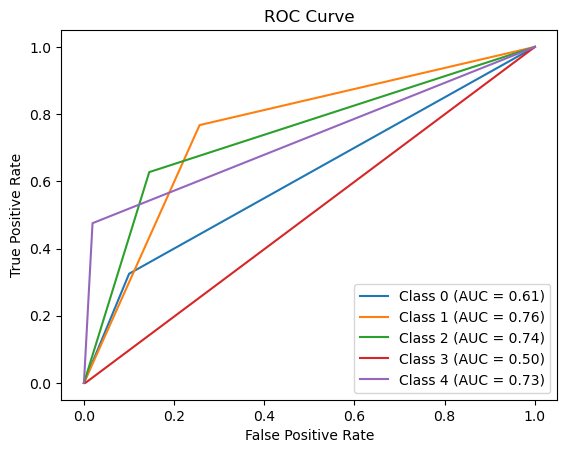

In [40]:
from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_auc_score, roc_curve

# Convert labels to binary format for ROC AUC
y_test_binary = label_binarize(y_test, classes=np.unique(y))
y_pred_binary = label_binarize(y_pred, classes=np.unique(y))

# Compute AUC for each class
for i in range(y_test_binary.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_binary[:, i], y_pred_binary[:, i])
    auc = roc_auc_score(y_test_binary[:, i], y_pred_binary[:, i])

    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {auc:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


## Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Flatten the data if it's multi-dimensional
X = X.reshape(X.shape[0], -1)  # Reshape to 2D if it's not already 2D

knn_cv = KNeighborsClassifier(n_neighbors=5)
cv_scores = cross_val_score(knn_cv, X, y, cv=5)  # 5-fold cross-validation

print(f"Cross-Validation Accuracy: {cv_scores.mean():.2f} ± {cv_scores.std():.2f}")


## Hyperparameter Tuning

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning for K
param_grid = {'n_neighbors': np.arange(1, 20)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Best K value: {grid.best_params_['n_neighbors']}")
